**Hiererchial Clustering**


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [11]:
df = pd.read_csv(r"C:\Users\LaptopWala\Downloads\iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
X = df.drop(columns = ['species'])

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [10]:
X_scaled.shape

(150, 4)

In [12]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)

In [13]:
pca_scaled = pca.fit_transform(X_scaled)

In [14]:
pca_scaled.shape

(150, 2)

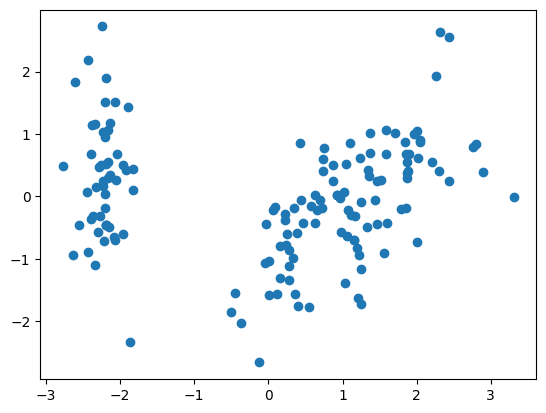

In [15]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1])

**Agglomerative Clustering**

In [16]:
import scipy.cluster.hierarchy as sc

Text(0, 0.5, 'euclidean distance')

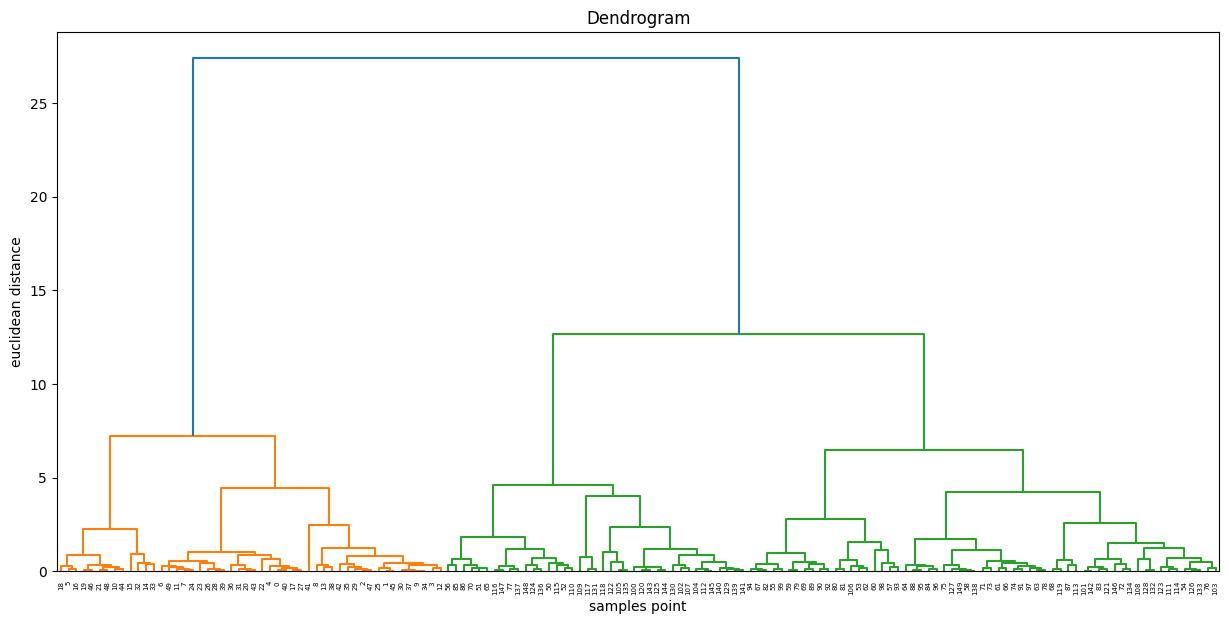

In [17]:
plt.figure(figsize = (15,7))
plt.title('Dendogram')
sc.dendrogram(sc.linkage(pca_scaled, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('samples point')
plt.ylabel('euclidean distance')

In [21]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward')
cluster.fit(pca_scaled)


,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [24]:
cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

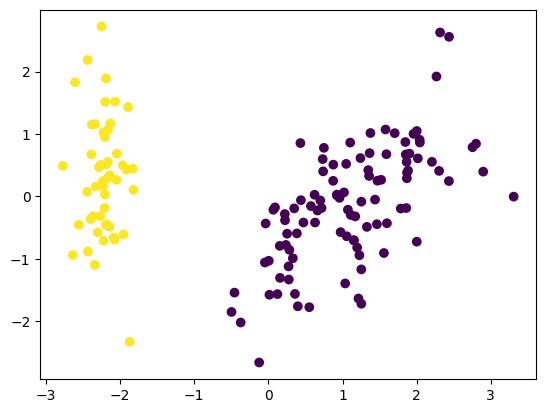

In [25]:
plt.scatter(pca_scaled[:, 0 ], pca_scaled[:,1], c = cluster.labels_)

In [33]:
from sklearn.metrics import silhouette_score
silhouette_coefficient = []
for k in range(2,10):
    cluster = AgglomerativeClustering(n_clusters = k , metric = 'euclidean', linkage = 'ward')
    cluster.fit(X_scaled)
    score = silhouette_score(X_scaled, cluster.labels_)
    silhouette_coefficient.append(score)

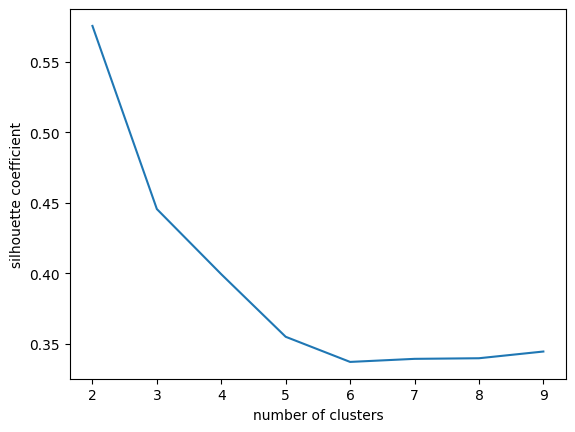

In [34]:
plt.plot(range(2,10), silhouette_coefficient)
plt.xticks(range(2,10))
plt.xlabel('number of clusters')
plt.ylabel('silhouette coefficient')
plt.show()